## Explainability for Deep Learning Models in Time Series Forecasting

##### **[Explainability for Deep Learning Models in Time Series Forecasting](https://medium.com/the-forecaster/34fb961b7725)**

> Explainability is a crucial aspect of machine learning that allows to understand and trust the predictions made from a model.

In [1]:
!pip install -qq neuralforecast captum pandas numpy matplotlib shap scikit-learn ipywidgets

In [3]:
import sys

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

import shap
import torch
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neuralforecast.core import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE, MSE

np.random.seed(42)
np.set_printoptions(precision=6, suppress=True)

torch.manual_seed(42)

pd.set_option("display.float_format", lambda x: "%.4f" % x)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (12, 8)

%autosave 10

Autosaving every 10 seconds


In [5]:
DATA_URL = "https://raw.githubusercontent.com/marcopeix/time-series-analysis/refs/heads/master/data/medium_views_published_holidays.csv"

df = pd.read_csv(DATA_URL, parse_dates=["ds"])
df.head()

,unique_id,ds,y,published,is_holiday
0,0,2020-01-01,1131,0.0000,1
1,0,2020-01-02,1764,0.0000,0
2,0,2020-01-03,1699,0.0000,0
3,0,2020-01-04,1322,0.0000,0
4,0,2020-01-05,1491,0.0000,0


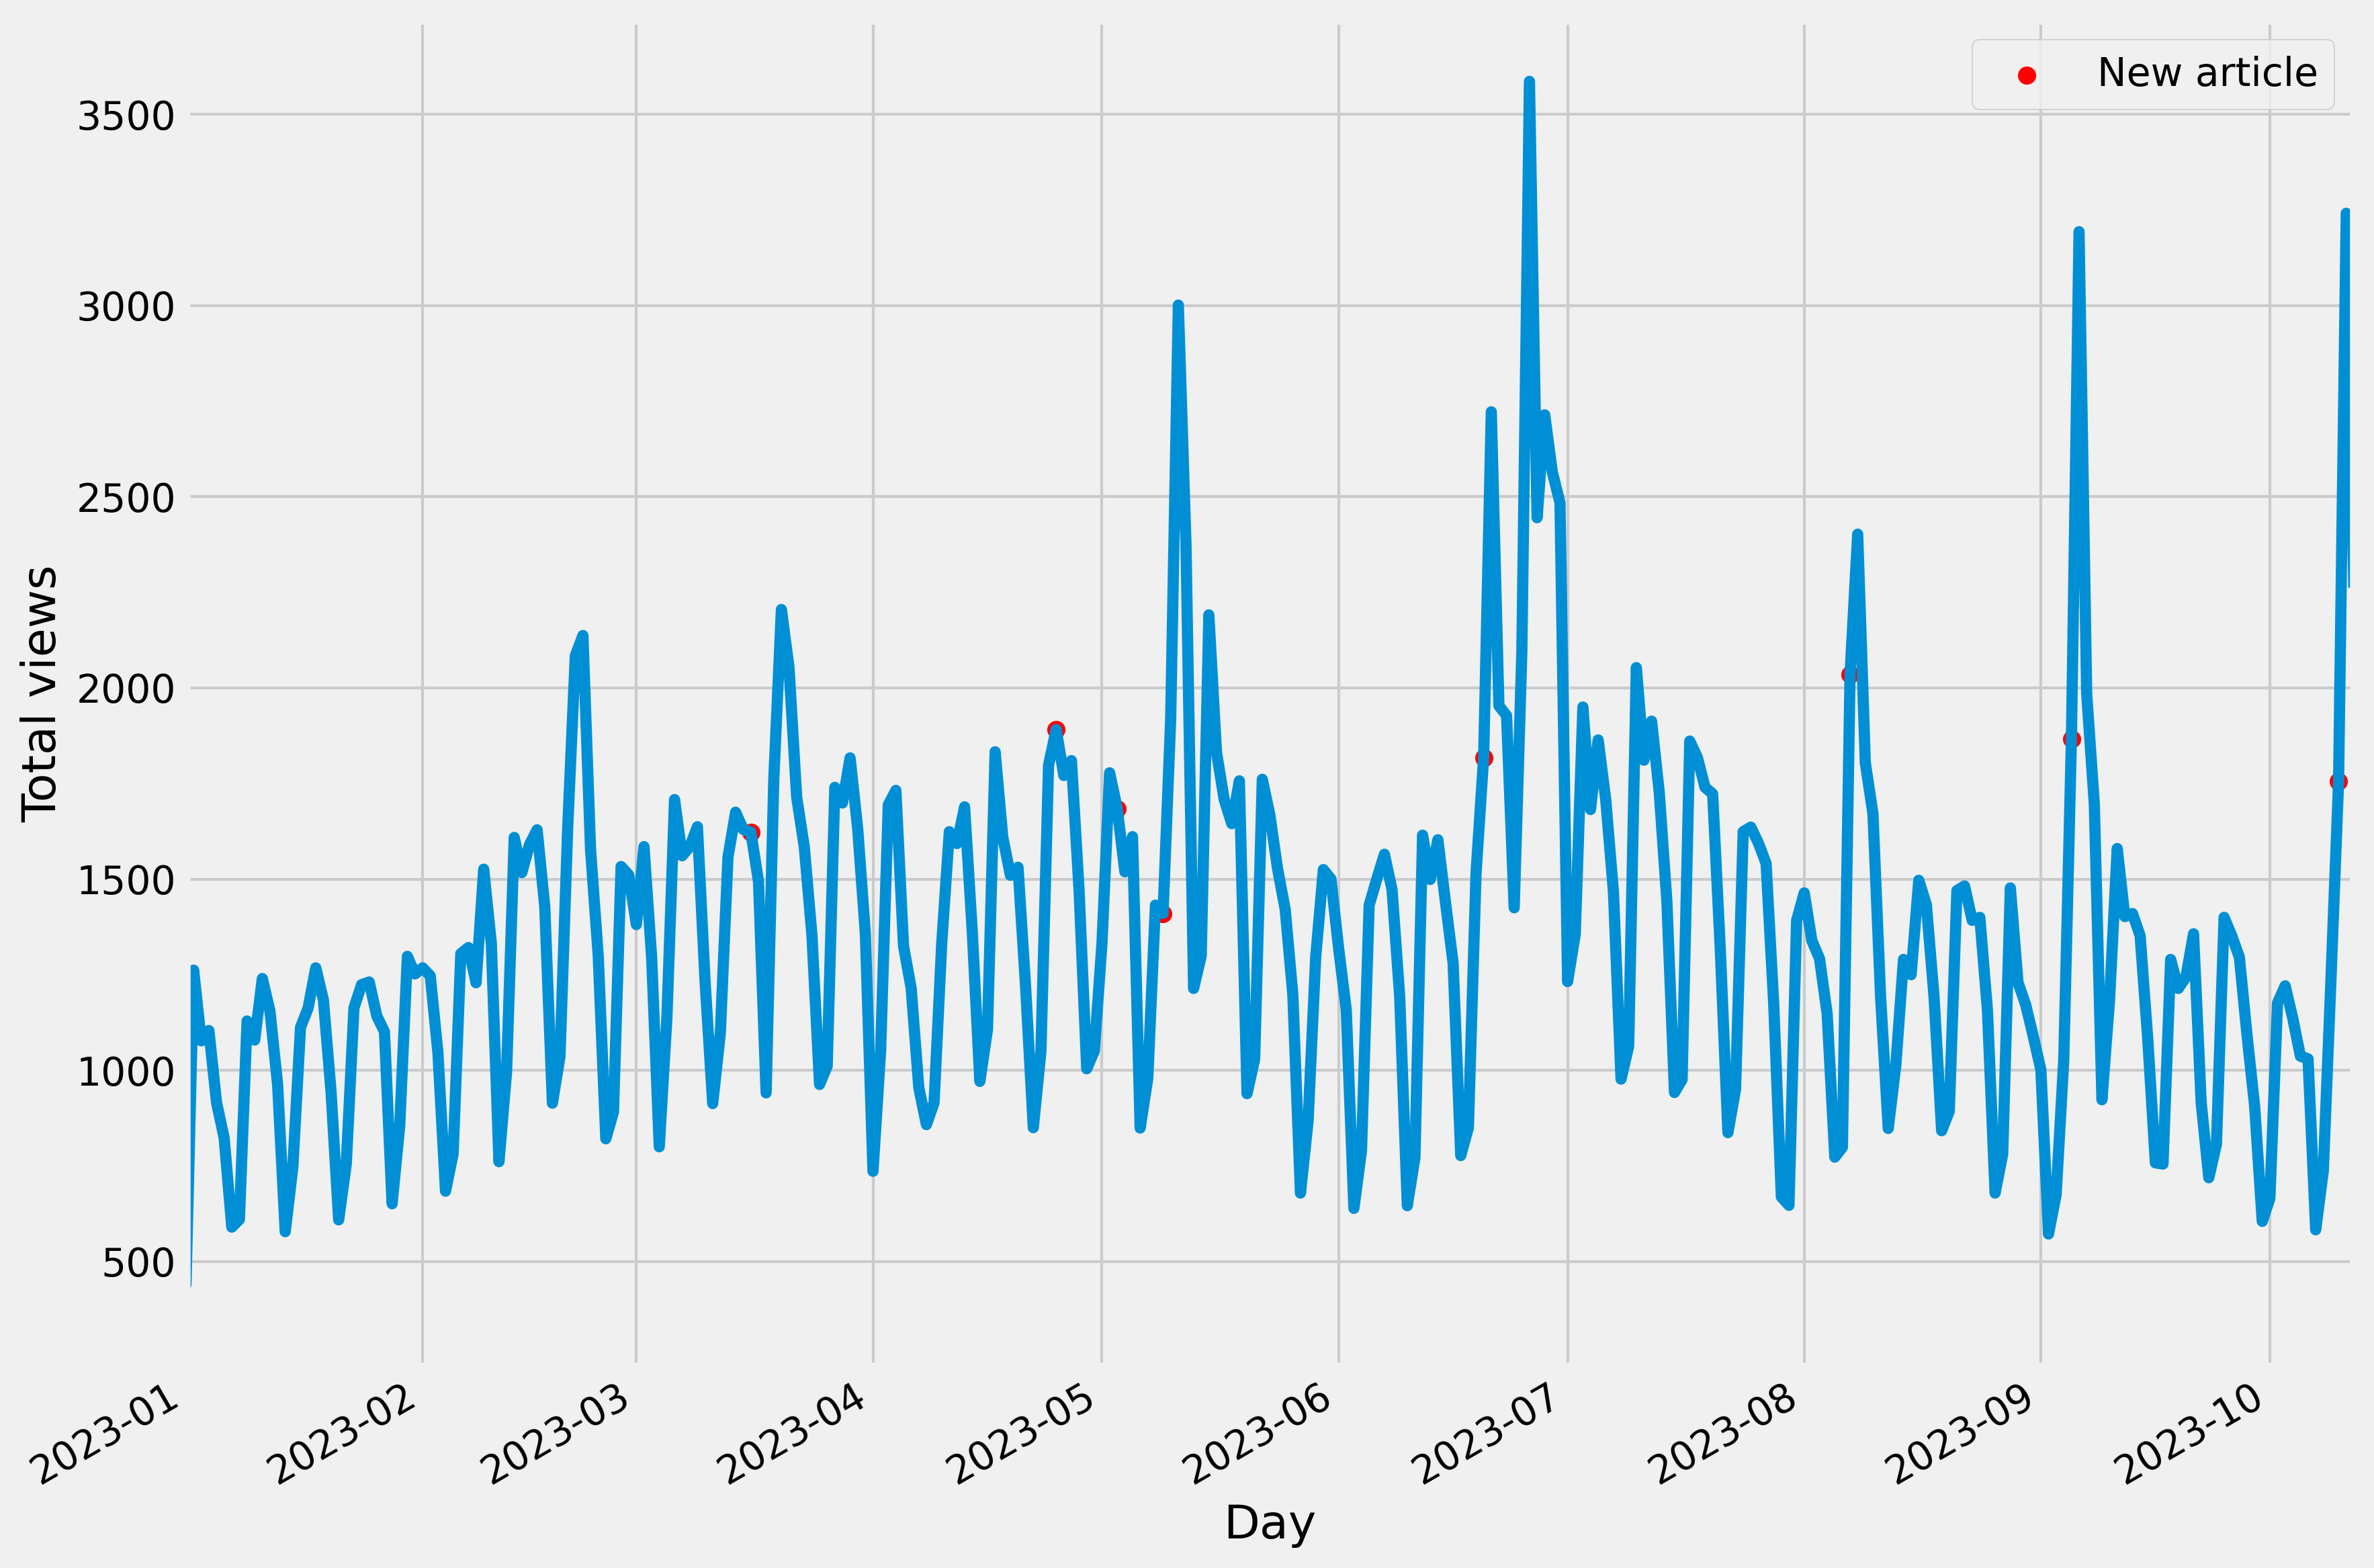

In [7]:
published_dates = df.query("published == 1")

fig, ax = plt.subplots(figsize=(12,8), dpi=300)

ax.plot(df['ds'], df['y'])
ax.scatter(published_dates['ds'], published_dates['y'], marker='o', color='red', label='New article')
ax.set_xlabel('Day')
ax.set_ylabel('Total views')
ax.legend(loc='best')
ax.set_xlim([datetime.date(2023, 1, 1), datetime.date(2023, 10, 12)])

fig.autofmt_xdate()

plt.tight_layout()

In [9]:
test = df.tail(28)
train = df.drop(test.index)

In [11]:
models = [
  NHITS(
    h=28,
    input_size=56,
    futr_exog_list=["published", "is_holiday"],
    max_steps=1000,
    loss=MSE(),
    valid_loss=MAE(),
    early_stop_patience_steps=3,
    scaler_type="robust",
    accelerator="cpu",
  ),
]

nf = NeuralForecast(
  models=models,
  freq="D",
)

nf.fit(df=train, val_size=28)

Epoch 399/-2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s v_num: 0.000 train_loss_step: 0.004 
                                                                               train_loss_epoch: 0.004 valid_loss: 
                                                                               954.113                             

In [13]:
futr_df = test.drop(columns=["y"])

fcsts_df, explanations = nf.explain(
  futr_df=futr_df,
  explainer="IntegratedGradients"
)

Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:01 • 0:00:00 0.00it/s

In [15]:
print(explanations["NHITS"]["insample"].shape)
print(explanations["NHITS"]["futr_exog"].shape)

torch.Size([1, 28, 1, 1, 56, 2])
torch.Size([1, 28, 1, 1, 2, 84])


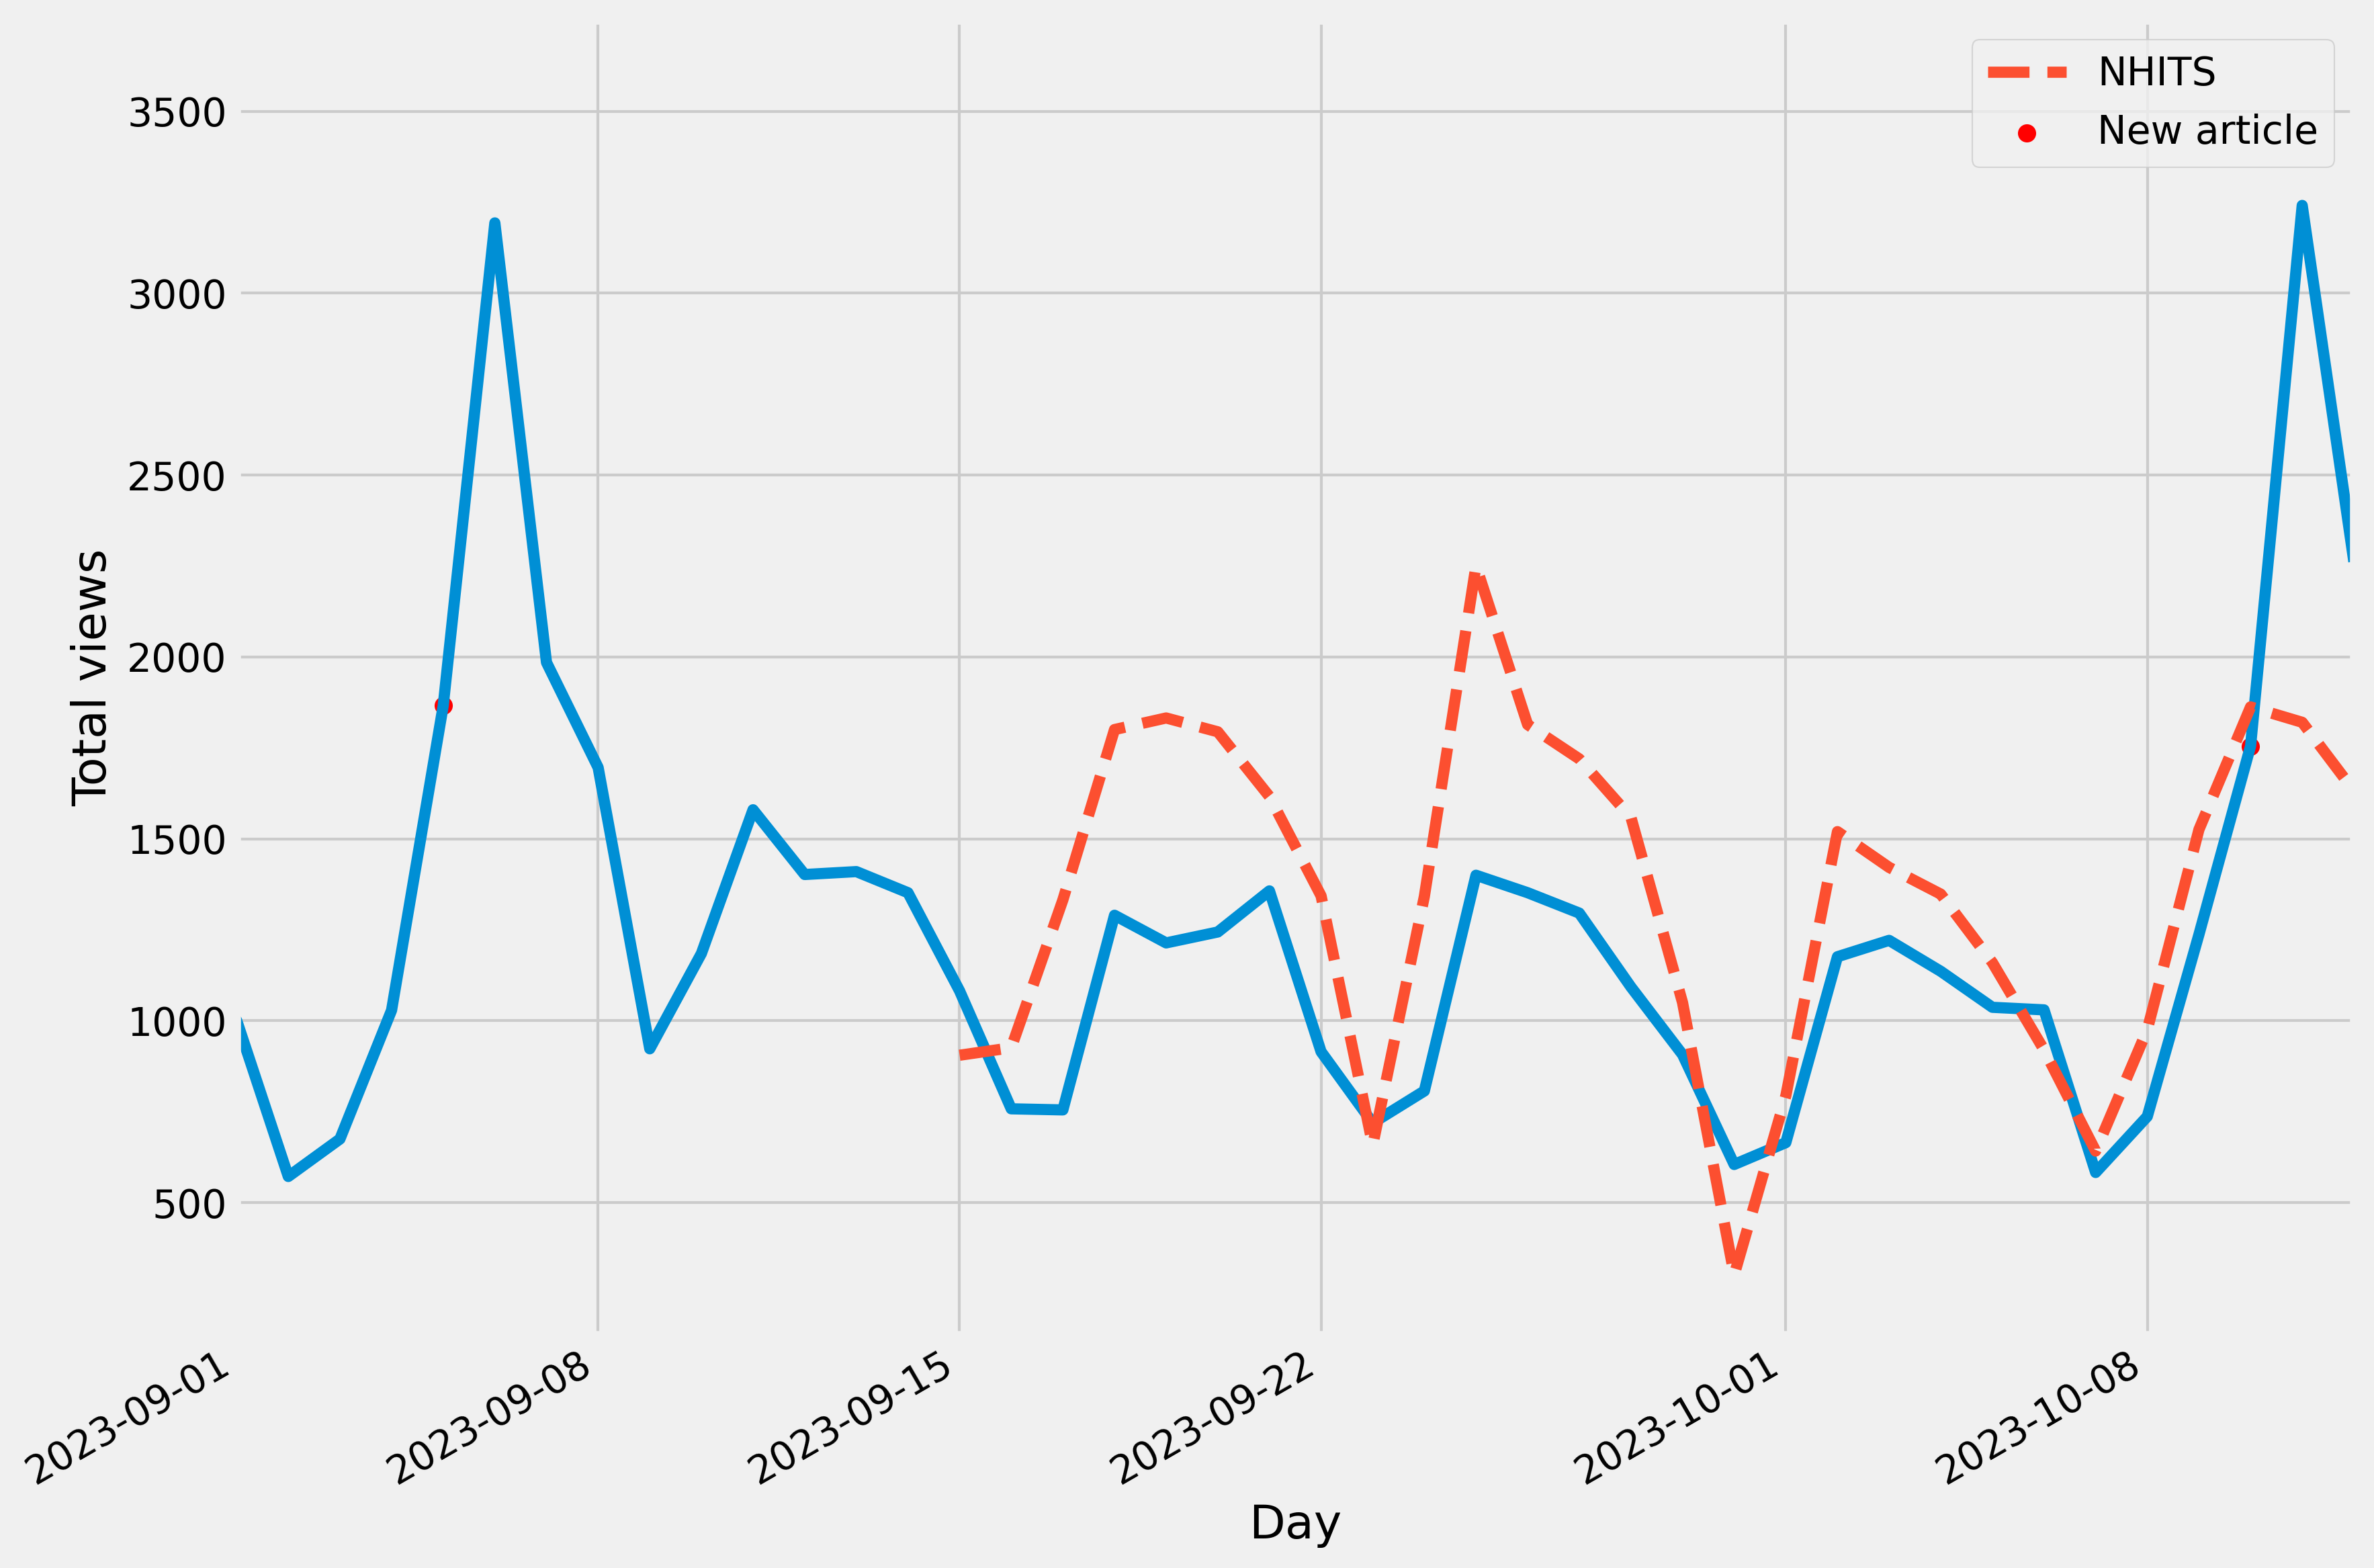

In [17]:
published_dates = df.query("published == 1")

fig, ax = plt.subplots(figsize=(12,8), dpi=300)

ax.plot(df['ds'], df['y'])
ax.plot(fcsts_df["ds"], fcsts_df["NHITS"], ls="--", label="NHITS")
ax.scatter(published_dates['ds'], published_dates['y'], marker='o', color='red', label='New article')
ax.set_xlabel('Day')
ax.set_ylabel('Total views')
ax.legend(loc='best')
ax.set_xlim([datetime.date(2023, 9, 1), datetime.date(2023, 10, 12)])

fig.autofmt_xdate()

plt.tight_layout()

In [19]:
holiday_idx = 24
published_idx = 25
batch_idx = 0
horizon_idx = published_idx
output_idx = 0

attributions = []
feature_names = []

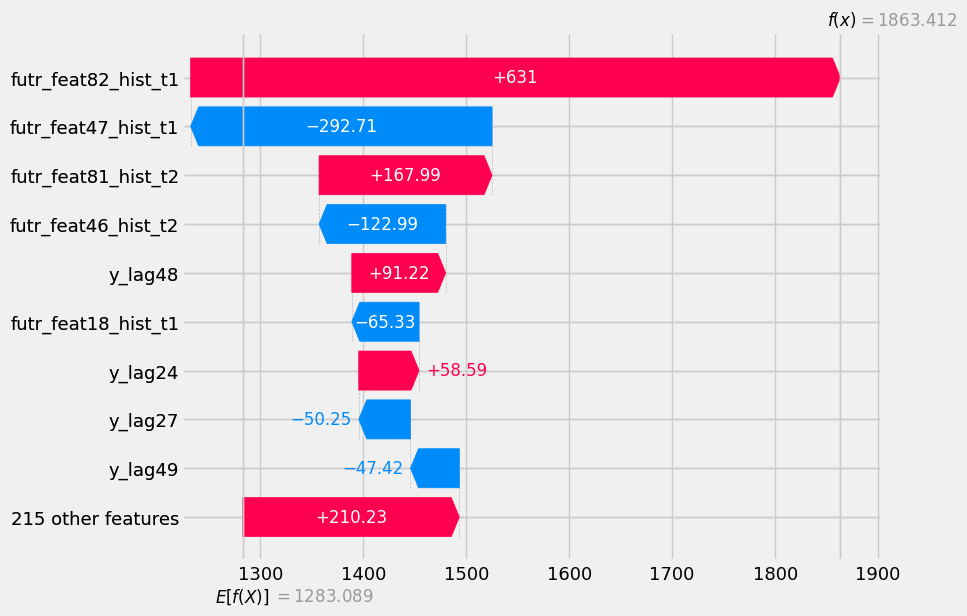

In [23]:
# Fixing the IndexError in SHAP waterfall construction by ensuring feature_names length matches attributions
# and guarding against incorrect indexing of feature_labels.

# Existing variables available from the notebook environment are reused:
# explanations, attributions, feature_names, batch_idx, horizon_idx, output_idx
# futr_attr, combined_insample, etc.

# Reset aggregation containers to avoid appending to old content if this cell is rerun
attributions = []
feature_names = []

# 1) Insample attributions (lags)
y_attr = explanations["NHITS"]["insample"][batch_idx, horizon_idx, 0, output_idx, :, 0]
mask_attr = explanations["NHITS"]["insample"][batch_idx, horizon_idx, 0, output_idx, :, 1]
combined_insample = (y_attr + mask_attr).cpu().numpy()
for i, attr in enumerate(combined_insample):
    attributions.append(float(attr))
    feature_names.append(f"y_lag{i+1}")

# 2) futr_exog attributions
futr_attr = explanations["NHITS"]["futr_exog"][batch_idx, horizon_idx, 0, output_idx]
futr_attr = futr_attr.cpu().numpy()  # shape expected (time=84, features=2)

# Ensure feature_labels length matches futr_attr second dimension to avoid IndexError
# If the model returns a different number/order of features, derive names programmatically.
expected_feat_count = futr_attr.shape[1]
predefined_labels = ["published", "is_holiday"]
if expected_feat_count == len(predefined_labels):
    feature_labels = predefined_labels
else:
    feature_labels = [f"futr_feat{j+1}" for j in range(expected_feat_count)]

# input_size and horizon inferred from shapes (from prior cells input_size=56, h=28)
input_size = combined_insample.shape[0]
# The time dimension of futr_attr should be input_size + h
total_time = futr_attr.shape[0]
h = total_time - input_size

for feat_idx in range(expected_feat_count):
    for t in range(total_time):
        attributions.append(float(futr_attr[t, feat_idx]))
        if t < input_size:
            feature_names.append(f"{feature_labels[feat_idx]}_hist_t{t+1}")
        else:
            feature_names.append(f"{feature_labels[feat_idx]}_futr_h{t - input_size + 1}")

# Sanity check to prevent SHAP from raising due to mismatched lengths
assert len(attributions) == len(feature_names), (
    f"Mismatch between attributions ({len(attributions)}) and feature names ({len(feature_names)})."
)

shap_values = np.array(attributions)

# baseline_predictions
baseline = float(explanations["NHITS"]["baseline_predictions"][batch_idx, horizon_idx, 0, output_idx].cpu())

# Create SHAP Explanation
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=baseline,
    feature_names=feature_names,
)

# Plot
shap.plots.waterfall(shap_explanation)

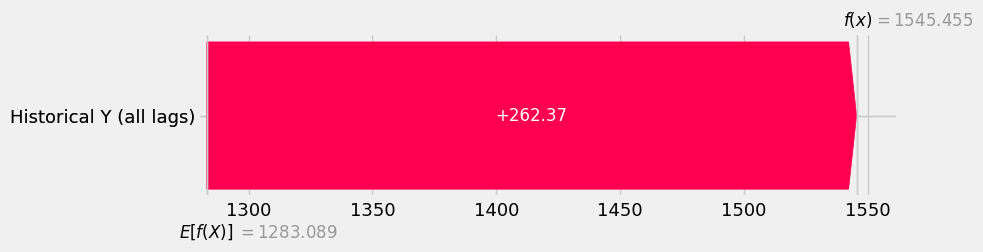

In [25]:
batch_idx = 0
horizon_idx = published_idx
output_idx = 0

baseline = float(explanations["NHITS"]["baseline_predictions"][batch_idx, horizon_idx, output_idx, output_idx].cpu())
insample_sum = float(explanations["NHITS"]["insample"][batch_idx, horizon_idx, output_idx, output_idx, :, :].sum().cpu())

# Separate sums for each future exogenous feature
published_sum = float(explanations["NHITS"]["futr_exog"][batch_idx, horizon_idx, output_idx, output_idx, :, 0].sum().cpu())
is_holiday_sum = float(explanations["NHITS"]["futr_exog"][batch_idx, horizon_idx, output_idx, output_idx, :, 1].sum().cpu())

feature_names = []
shap_values = []

if insample_sum != 0:
  feature_names.append("Historical Y (all lags)")
  shap_values.append(insample_sum)

if published_sum != 0:
  feature_names.append("Published (futr_exog)")
  shap_values.append(published_sum)

if is_holiday_sum != 0:
  feature_names.append("Is Holiday (futr_exog)")
  shap_values.append(is_holiday_sum)

shap_values = np.array(shap_values)

# Create SHAP Explanation
shap_explanation = shap.Explanation(
  values=shap_values,
  base_values=baseline,
  feature_names=feature_names
)

shap.plots.waterfall(shap_explanation)

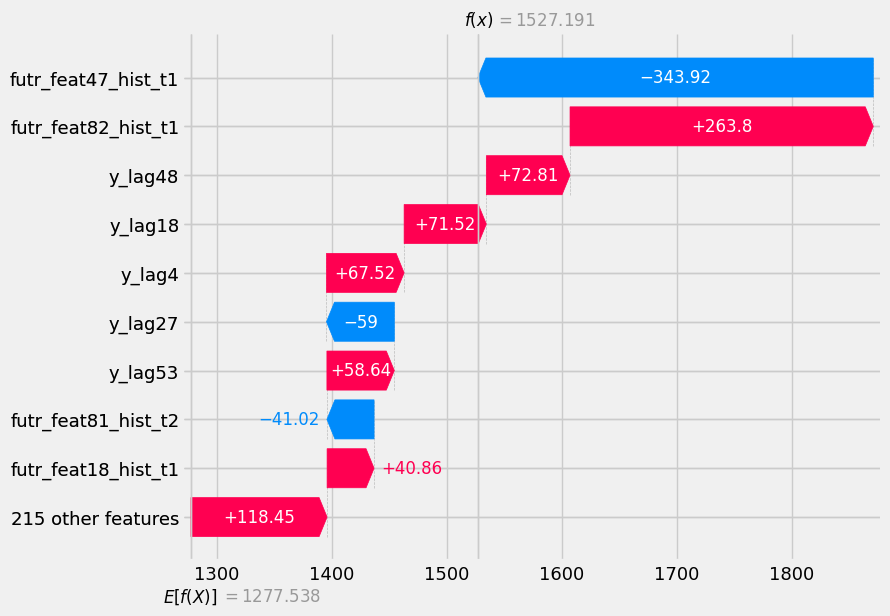

In [29]:
# Fix the IndexError by ensuring feature_labels indexing matches the actual number of futr_exog features,
# and construct feature_names dynamically from the returned tensor shapes. Also ensure all arrays are Python floats.

# Reuse existing notebook variables: explanations, holiday_idx

import numpy as np
import shap

batch_idx = 0
horizon_idx = holiday_idx
output_idx = 0

# Reset containers
attributions = []
feature_names = []

# Insample attributions (lags)
y_attr = explanations["NHITS"]["insample"][batch_idx, horizon_idx, 0, output_idx, :, 0]
mask_attr = explanations["NHITS"]["insample"][batch_idx, horizon_idx, 0, output_idx, :, 1]
combined_insample = (y_attr + mask_attr).cpu().numpy()
for i, attr in enumerate(combined_insample):
    attributions.append(float(attr))
    feature_names.append(f"y_lag{i+1}")

# futr_exog attributions
futr_attr = explanations["NHITS"]["futr_exog"][batch_idx, horizon_idx, 0, output_idx]
futr_attr = futr_attr.cpu().numpy()  # shape (time, features)

# Determine feature labels robustly to avoid IndexError
predefined_labels = ["published", "is_holiday"]
expected_feat_count = futr_attr.shape[1]
if expected_feat_count == len(predefined_labels):
    feature_labels = predefined_labels
else:
    # Fallback to generic names if counts mismatch
    feature_labels = [f"futr_feat{j+1}" for j in range(expected_feat_count)]

# Derive input_size and horizon from shapes to avoid hard-coding indices
input_size = combined_insample.shape[0]
TotalT = futr_attr.shape[0]
# TotalT should be input_size + h; keep generic

for feat_idx in range(expected_feat_count):
    for t in range(TotalT):
        attributions.append(float(futr_attr[t, feat_idx]))
        if t < input_size:
            feature_names.append(f"{feature_labels[feat_idx]}_hist_t{t+1}")
        else:
            feature_names.append(f"{feature_labels[feat_idx]}_futr_h{t - input_size + 1}")

# Sanity check lengths match
assert len(attributions) == len(feature_names), (
    f"Mismatch between attributions ({len(attributions)}) and feature names ({len(feature_names)})."
)

shap_values = np.array(attributions)

# baseline_predictions
baseline = float(explanations["NHITS"]["baseline_predictions"][batch_idx, horizon_idx, 0, output_idx].cpu())

# Create SHAP Explanation
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=baseline,
    feature_names=feature_names,
)

shap.plots.waterfall(shap_explanation)

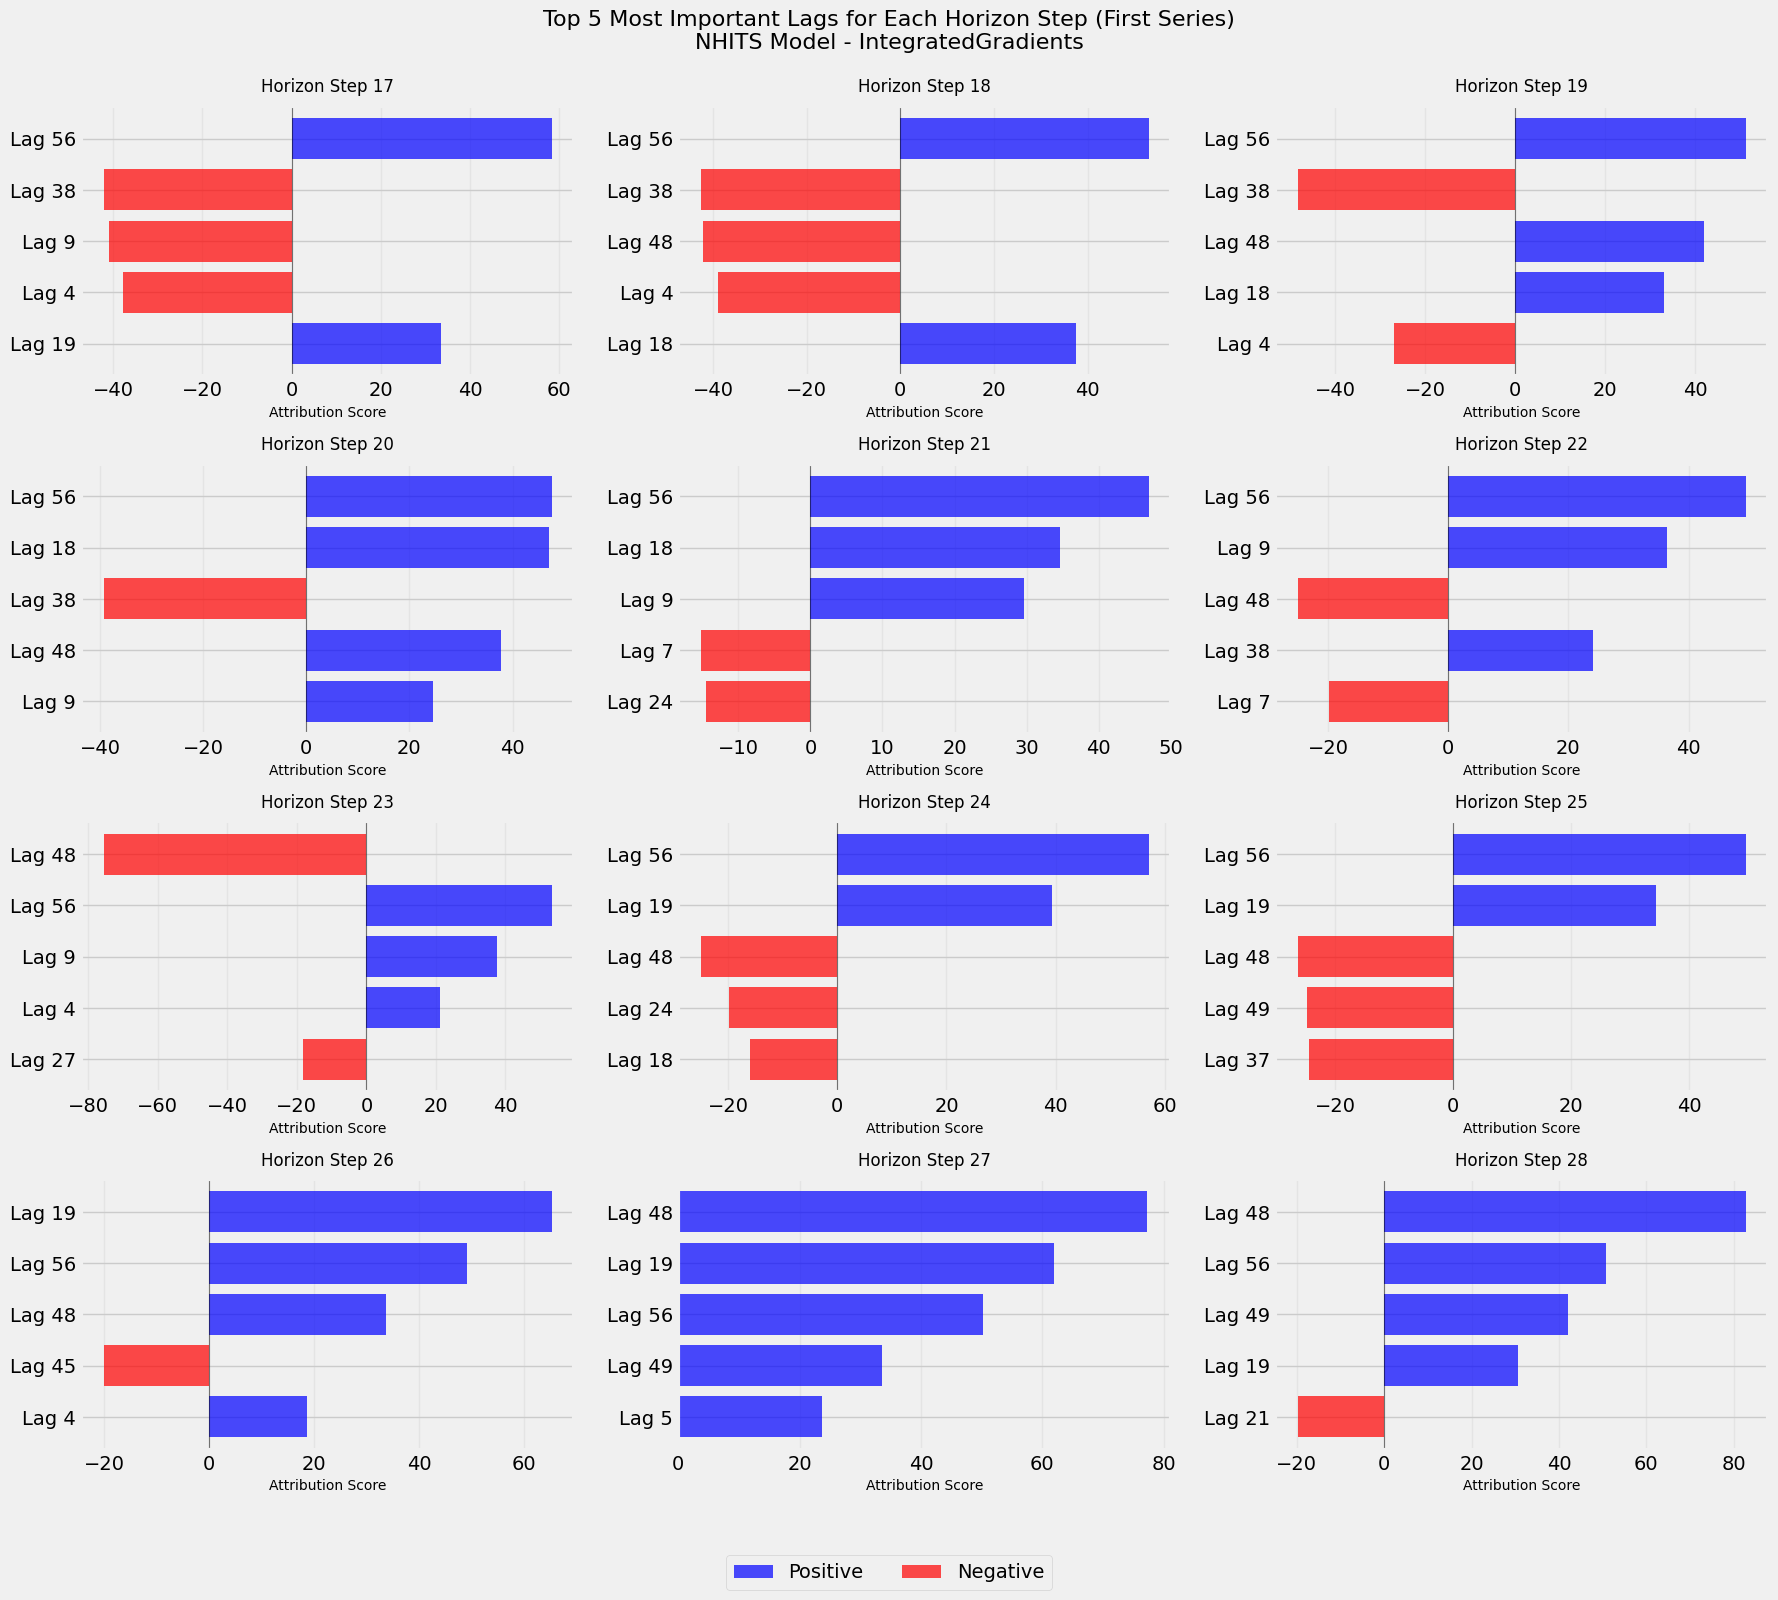

In [31]:
data = explanations["NHITS"]["insample"][0, :-12, 0, 0, :, 0]  # Shape: [12, 56]

# Create 4x3 subplot grid
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for h in range(12):
  horizon_attrs = data[h, :].cpu().numpy()

  # Get top 5 lags by absolute value
  top5_indices = np.argsort(np.abs(horizon_attrs))[-5:]
  top5_values = horizon_attrs[top5_indices]
  top5_lags = top5_indices + 1

  # Sort by absolute value (most important at top)
  sort_order = np.argsort(np.abs(top5_values))

  # Create horizontal bar plot
  colors = ['red' if v < 0 else 'blue' for v in top5_values[sort_order]]
  axes[h].barh(range(5), top5_values[sort_order], color=colors, alpha=0.7)
  axes[h].set_yticks(range(5))
  axes[h].set_yticklabels([f'Lag {lag}' for lag in top5_lags[sort_order]])
  axes[h].set_title(f'Horizon Step {h+17}', fontsize=12, pad=10)
  axes[h].axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=0.8)
  axes[h].grid(axis='x', alpha=0.3)
  axes[h].set_xlabel('Attribution Score', fontsize=10)

plt.suptitle('Top 5 Most Important Lags for Each Horizon Step (First Series)\nNHITS Model - IntegratedGradients',
             fontsize=16, y=0.98)

# Add legend
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor='blue', alpha=0.7, label='Positive'),
                    Patch(facecolor='red', alpha=0.7, label='Negative')],
          loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)

plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.08)
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=662c0d72-2bf2-40b4-938b-299696a15672' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>